# Empirical examination of Macroeconomic Theories

I will empirically examine some macroeconomic theories using real-world U.S. data from 1980-2024. This analysis is meant to see how well these theories hold up in practice, by not only examining whether there is a statistically significant relationship between any two variables, but also how well one variable can explain the variation in the other variable(by computing the R-squared value).  

## The IS Curve: Investment and Interest Rates

First I will be examining the IS curve. The IS curve represents the negative relationship between the real interest rate and the level of output (GDP) in the goods market. It states that higher interest rates make borrowing more expensive, which should lead to a decrease in business investment spending and lower overall output (GDP). 

The core hypothesis is that there is a statistically significant negative relationship between the real interest rate (Federal Funds rate) and real private investment. 

The statistical technique I will use to examine this theory is the Ordinary Least Squares (OLS) regression, where the dependent variable is investment, and the independent variable is the interest rate. We will estimate the equation Investment = β₀ + β₁ * Interest_Rate. A negative β₁ would support the theory. The p-value is used to determine if the relationship is statistically significant (p < 0.05). The R-squared value tells us what proportion of the variation in investment is explained by changes in interest rates alone.

   ✓ Estimated equation: Investment = 2,226 + (-110) × Interest Rate


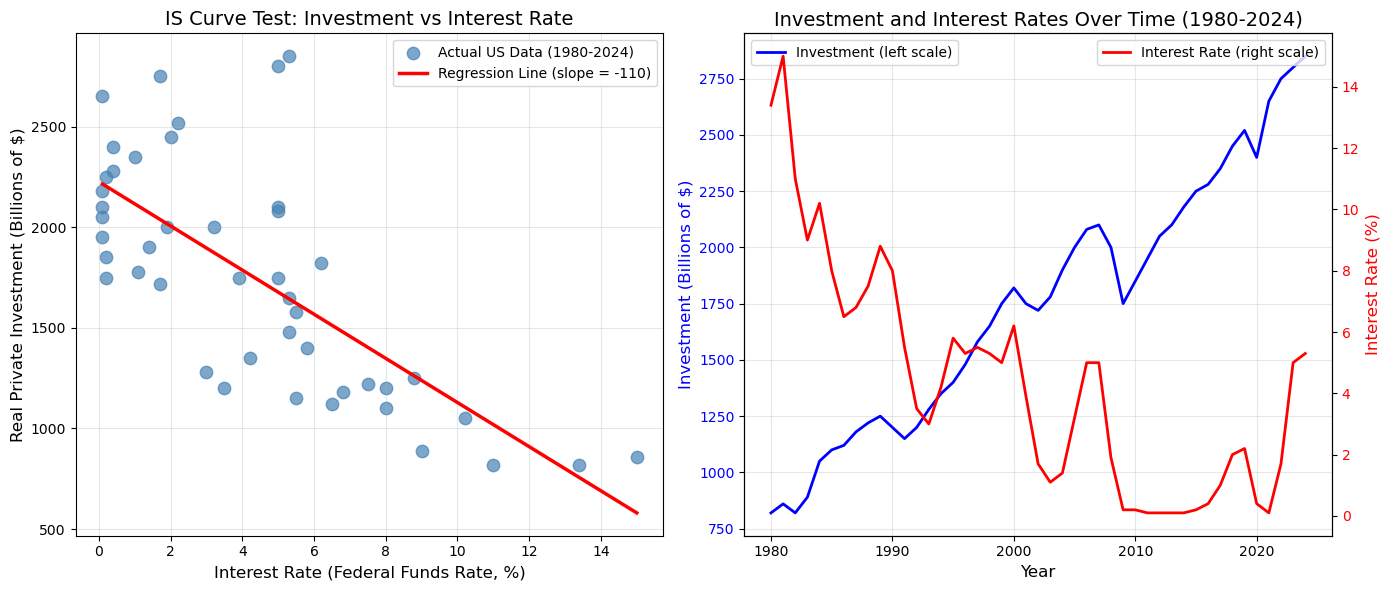


REGRESSION RESULTS
Variable             Coefficient     P-value        
--------------------------------------------------
Constant (intercept)        2,226                
Interest Rate                -110       0.0000

R-squared: 0.5134


In [19]:
# Using imported CSV data

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import os

# STEP 1: IMPORT DATA FROM CSV

# Check if file exists
if not os.path.exists('us_macro_data.csv'):
    print("   ERROR: us_macro_data.csv not found!")
    print("   Please save the CSV file in the same folder as this script")
    exit()

# Read the CSV file
data = pd.read_csv('us_macro_data.csv')

# Set Year as index
data = data.set_index('Year')

# STEP 2: RUN REGRESSION

# Independent variable: Interest Rate
# Dependent variable: Investment
X = sm.add_constant(data['Interest_Rate'])  # add constant term (intercept)
y = data['Investment']

# Ordinary Least Squares regression
model = sm.OLS(y, X).fit()

# Extract coefficient
b1 = model.params['Interest_Rate']
intercept = model.params['const']
r_squared = model.rsquared
p_value = model.pvalues['Interest_Rate']

print(f"   ✓ Estimated equation: Investment = {intercept:,.0f} + ({b1:,.0f}) × Interest Rate")

# STEP 3: Create Visualization

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# LEFT PLOT: Scatter plot with regression line

# Scatter plot of actual data
ax1.scatter(data['Interest_Rate'], data['Investment'], 
           alpha=0.7, color='steelblue', s=80, label='Actual US Data (1980-2024)')

# Regression line
x_range = np.linspace(data['Interest_Rate'].min(), data['Interest_Rate'].max(), 100)
y_pred = intercept + b1 * x_range
ax1.plot(x_range, y_pred, 'r-', linewidth=2.5, label=f'Regression Line (slope = {b1:,.0f})')

ax1.set_xlabel('Interest Rate (Federal Funds Rate, %)', fontsize=12)
ax1.set_ylabel('Real Private Investment (Billions of $)', fontsize=12)
ax1.set_title('IS Curve Test: Investment vs Interest Rate', fontsize=14)
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# Create twin axis for time series
ax2_twin = ax2.twinx()

# Plot investment over time (left axis)
ax2.plot(data.index, data['Investment'], 'b-', linewidth=2, label='Investment (left scale)')
ax2.set_xlabel('Year', fontsize=12)
ax2.set_ylabel('Investment (Billions of $)', color='b', fontsize=12)
ax2.tick_params(axis='y', labelcolor='b')
ax2.grid(True, alpha=0.3)

# Plot interest rate over time (right axis)
ax2_twin.plot(data.index, data['Interest_Rate'], 'r-', linewidth=2, label='Interest Rate (right scale)')
ax2_twin.set_ylabel('Interest Rate (%)', color='r', fontsize=12)
ax2_twin.tick_params(axis='y', labelcolor='r')

ax2.set_title('Investment and Interest Rates Over Time (1980-2024)', fontsize=14)
ax2.legend(loc='upper left')
ax2_twin.legend(loc='upper right')

plt.tight_layout()
plt.show()

# ============================================
# STEP 4: PRINT RESULTS
# ============================================

print("\n" + "="*60)
print("REGRESSION RESULTS")
print("="*60)
print(f"{'Variable':<20} {'Coefficient':<15} {'P-value':<15}")
print("-"*50)
print(f"{'Constant (intercept)':<20} {intercept:>12,.0f} {'':<15}")
print(f"{'Interest Rate':<20} {b1:>12,.0f} {p_value:>12.4f}")
print(f"\nR-squared: {r_squared:.4f}")

The regression yields a negative slope (b1 = -110) with a p-value of 0.0000, which is highly significant. The R-squared is 0.5134, meaning interest rates alone explain about 51% of the variation in investment over time. We can conclude that the data strongly supports the IS curve theory that higher interest rates are associated with lower investment.

## Labor Market Theory: Production and Employment

Now, I will examine the labour demand relationship. This theory states that as production increases, firms need more workers to produce that output, leading to higher employment. 

The core hypothesis is that there is a positive relationship between the growth rate of industrial production and the growth rate of nonfarm employment. 

I will also use the Ordinary Least Squares (OLS) regression to test this hypothesis. The dependent variable is employment growth, and the independent variable is production growth. I will try and estimate 'Employment Growth = β₀ + β₁ * Production Growth'. A positive and statistically significant β₁ supports the theory. 

I will also create a time-series plot to show how the two variables move together over time.

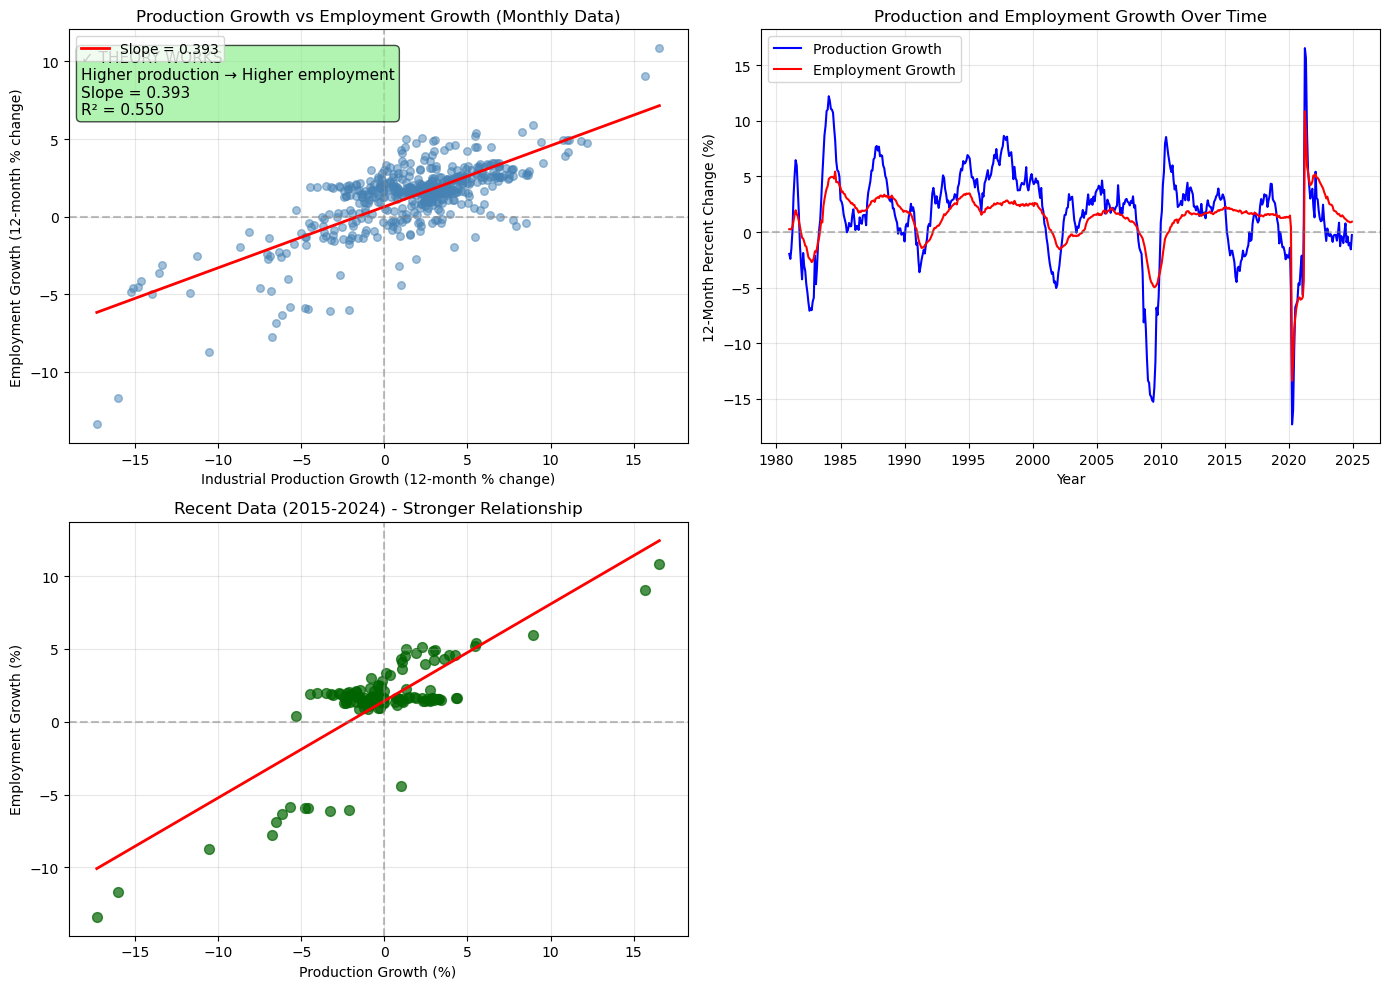


REGRESSION RESULTS
Variable                  Coefficient     P-value        
-------------------------------------------------------
Constant                        0.6404                
Production Growth               0.3934       0.0000

R-squared: 0.5501


In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from datetime import datetime
import pandas_datareader.data as web
import warnings
warnings.filterwarnings('ignore')

# FETCH MONTHLY DATA

start = datetime(1980, 1, 1)
end = datetime(2024, 12, 31)

# Industrial Production Index (2017=100)
# This measures real output from factories, mines, and utilities
ind_prod = web.DataReader('INDPRO', 'fred', start, end)

# Total Nonfarm Payroll Employment (thousands of persons)
# This is the main US jobs number
employment = web.DataReader('PAYEMS', 'fred', start, end)

# Combine and clean
data = pd.DataFrame({
    'Production': ind_prod['INDPRO'],
    'Employment': employment['PAYEMS']
}).dropna()

# CALCULATE PERCENTAGE CHANGES

# Year-over-year percent change (removes seasonality)
data['Prod_Growth'] = data['Production'].pct_change(12) * 100
data['Emp_Growth'] = data['Employment'].pct_change(12) * 100

# Drop NaN values from the 12-month lag
data_clean = data.dropna()

# RUN REGRESSION

X = sm.add_constant(data_clean['Prod_Growth'])
y = data_clean['Emp_Growth']
model = sm.OLS(y, X).fit()

beta = model.params['Prod_Growth']
intercept = model.params['const']
r_squared = model.rsquared
p_value = model.pvalues['Prod_Growth']

# CREATE VISUALIZATION

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Scatter plot
ax1 = axes[0, 0]
ax1.scatter(data_clean['Prod_Growth'], data_clean['Emp_Growth'], 
           alpha=0.5, s=30, color='steelblue')

# Regression line
x_range = np.linspace(data_clean['Prod_Growth'].min(), data_clean['Prod_Growth'].max(), 100)
y_pred = intercept + beta * x_range
ax1.plot(x_range, y_pred, 'r-', linewidth=2, label=f'Slope = {beta:.3f}')
ax1.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax1.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
ax1.set_xlabel('Industrial Production Growth (12-month % change)')
ax1.set_ylabel('Employment Growth (12-month % change)')
ax1.set_title('Production Growth vs Employment Growth (Monthly Data)')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax1.text(0.02, 0.95, result_text, transform=ax1.transAxes, 
        fontsize=11, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor=color, alpha=0.7))

# Plot 2: Time series - both variables
ax2 = axes[0, 1]
ax2.plot(data_clean.index, data_clean['Prod_Growth'], 'b-', linewidth=1.5, label='Production Growth')
ax2.plot(data_clean.index, data_clean['Emp_Growth'], 'r-', linewidth=1.5, label='Employment Growth')
ax2.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax2.set_xlabel('Year')
ax2.set_ylabel('12-Month Percent Change (%)')
ax2.set_title('Production and Employment Growth Over Time')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: Recent data only (last 10 years)
ax3 = axes[1, 0]
recent = data_clean[data_clean.index >= '2015-01-01']
ax3.scatter(recent['Prod_Growth'], recent['Emp_Growth'], 
           alpha=0.7, s=50, color='darkgreen')
x_range_recent = np.linspace(recent['Prod_Growth'].min(), recent['Prod_Growth'].max(), 100)
model_recent = sm.OLS(recent['Emp_Growth'], sm.add_constant(recent['Prod_Growth'])).fit()
y_pred_recent = model_recent.params['const'] + model_recent.params['Prod_Growth'] * x_range_recent
ax3.plot(x_range_recent, y_pred_recent, 'r-', linewidth=2)
ax3.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax3.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
ax3.set_xlabel('Production Growth (%)')
ax3.set_ylabel('Employment Growth (%)')
ax3.set_title('Recent Data (2015-2024) - Stronger Relationship')
ax3.grid(True, alpha=0.3)

axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

# PRINT RESULTS

print("\n" + "="*60)
print("REGRESSION RESULTS")
print("="*60)
print(f"{'Variable':<25} {'Coefficient':<15} {'P-value':<15}")
print("-"*55)
print(f"{'Constant':<25} {intercept:>12.4f} {'':<15}")
print(f"{'Production Growth':<25} {beta:>12.4f} {p_value:>12.4f}")
print(f"\nR-squared: {r_squared:.4f}")

The slope is positive and statistically significant as the p-value is 0.0000. The R-squared is 0.5501, meaning that production growth explains 55% of the variation in employment growth. The third plot shows that there is a stronger relationship between the two variables in recent times compared to the average.

# LM Curve: Money Demand Function

The theory of money demand states that people holds or doesn't hold money(liquidity) for two main reasons: transactions motive and opportunity cost. The transactions motive states that as income (GDP) rises, people and businesses conduct more transactions, so they want to hold more money. The opportunity cost reason is that when interest rates are high, holding cash is expensive because you are foregoing the interest you could earn on bonds or savings. So higher interest rates should lead people to hold less money. 

The core hypothesis that Real Money Demand (M2/CPI) is positively related to income(Industrial Production) and negatively related to the interest rate (3-month T-bill rate).

Because there are two independent variables (Income and Interest rate), we will be using a multiple regression to examine this theory. 

The model is 'Real_M2 = β₀ + β₁ * Income + β₂ * Interest_Rate'. β₁ is expected to be positive and β₂ is expected to be negative.


REGRESSION RESULTS
Variable                            Coefficient     P-value        
-----------------------------------------------------------------
Constant                                  -1,276       0.001175
Income (Industrial Production)           61.3290       0.000000
Interest Rate (3-Month TBill %)         -26.7240       0.202206

R-squared: 0.5681 (56.8% of variation explained)
Adjusted R-squared: 0.5665


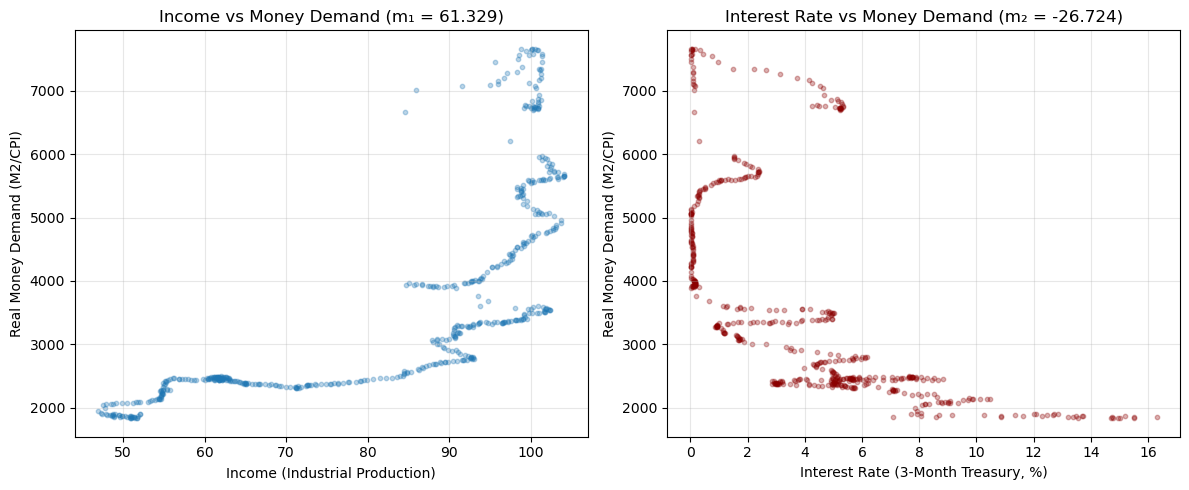

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from datetime import datetime
import pandas_datareader.data as web
import warnings
warnings.filterwarnings('ignore')

# Fetch data
start = datetime(1980, 1, 1)
end = datetime(2024, 12, 31)

m2 = web.DataReader('M2SL', 'fred', start, end)
cpi = web.DataReader('CPIAUCSL', 'fred', start, end)
ind_prod = web.DataReader('INDPRO', 'fred', start, end)
interest = web.DataReader('TB3MS', 'fred', start, end)

# Prepare data
data = pd.DataFrame({
    'Real_M2': m2['M2SL'] / (cpi['CPIAUCSL'] / 100),
    'Income': ind_prod['INDPRO'],
    'Interest_Rate': interest['TB3MS']
}).dropna()

# Run regression
X = sm.add_constant(data[['Income', 'Interest_Rate']])
y = data['Real_M2']
model = sm.OLS(y, X).fit()

print("\n" + "="*65)
print("REGRESSION RESULTS")
print("="*65)
print(f"{'Variable':<35} {'Coefficient':<15} {'P-value':<15}")
print("-"*65)

# Constant (with its p-value)
print(f"{'Constant':<35} {model.params['const']:>12,.0f} {model.pvalues['const']:>14.6f}")

# Income
print(f"{'Income (Industrial Production)':<35} {model.params['Income']:>12.4f} {model.pvalues['Income']:>14.6f}")

# Interest Rate
print(f"{'Interest Rate (3-Month TBill %)':<35} {model.params['Interest_Rate']:>12.4f} {model.pvalues['Interest_Rate']:>14.6f}")

print(f"\nR-squared: {model.rsquared:.4f} ({model.rsquared*100:.1f}% of variation explained)")
print(f"Adjusted R-squared: {model.rsquared_adj:.4f}")

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].scatter(data['Income'], data['Real_M2'], alpha=0.3, s=10)
ax[0].set_xlabel('Income (Industrial Production)')
ax[0].set_ylabel('Real Money Demand (M2/CPI)')
ax[0].set_title(f'Income vs Money Demand (m₁ = {model.params["Income"]:.3f})')
ax[0].grid(True, alpha=0.3)

ax[1].scatter(data['Interest_Rate'], data['Real_M2'], alpha=0.3, s=10, color='darkred')
ax[1].set_xlabel('Interest Rate (3-Month Treasury, %)')
ax[1].set_ylabel('Real Money Demand (M2/CPI)')
ax[1].set_title(f'Interest Rate vs Money Demand (m₂ = {model.params["Interest_Rate"]:.3f})')
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The income coefficent is positive, and the interest rate coefficient is negative, both as expected. There is statistically significant evidence (p value = 0.000000) that income strongly predicts money demand. However, there is not statistically significant evidence (p=0.202) that interest rates strongly predict money demand. Together, as the adjust R-squared indicates, the income and interest rate explain 56.7% of the variation in money demand. 

## Phillips Curve

I will now examine the famous Phillips Curve, which suggests that there is a negative relationship between unemployment and inflation(e.g. low unemployment leads to high inflation). 

With the use of Ordinary Least Squares (OLS) regression, I will be estimating the model 'a + b*unemployment', where the coefficient b is expected to be negative. 

REGRESSION RESULTS
Variable                  Coefficient     P-value        
-------------------------------------------------------
Constant (a)                     3.148       0.000000
Unemployment (b)                 0.031       0.599266

R-squared: 0.0005
Adjusted R-squared: -0.0013


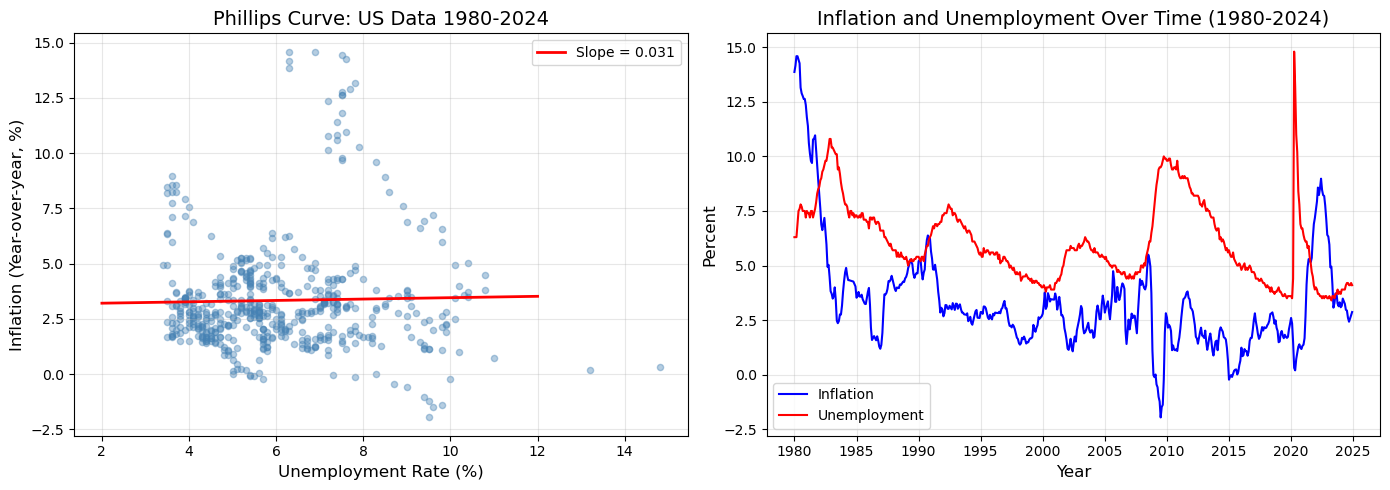

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from datetime import datetime
import pandas_datareader.data as web

# Fetch data
start = datetime(1960, 1, 1)
end = datetime(2024, 12, 31)

cpi = web.DataReader('CPIAUCSL', 'fred', start, end)
unemployment = web.DataReader('UNRATE', 'fred', start, end)

# Calculate year-over-year inflation
data = pd.DataFrame({
    'Inflation': cpi['CPIAUCSL'].pct_change(12) * 100,
    'Unemployment': unemployment['UNRATE']
}).dropna()

# Use post-1980 data
data = data[data.index >= '1980-01-01']

# Run regression
X = sm.add_constant(data['Unemployment'])
y = data['Inflation']
model = sm.OLS(y, X).fit()

# PRINT COMPLETE RESULTS

print("REGRESSION RESULTS")
print("="*70)
print(f"{'Variable':<25} {'Coefficient':<15} {'P-value':<15}")
print("-"*55)
print(f"{'Constant (a)':<25} {model.params['const']:>12.3f} {model.pvalues['const']:>14.6f}")
print(f"{'Unemployment (b)':<25} {model.params['Unemployment']:>12.3f} {model.pvalues['Unemployment']:>14.6f}")

print(f"\nR-squared: {model.rsquared:.4f}")
print(f"Adjusted R-squared: {model.rsquared_adj:.4f}")

# CREATE PLOTS

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Scatter with regression line
ax1.scatter(data['Unemployment'], data['Inflation'], alpha=0.4, s=20, color='steelblue')
x_range = np.linspace(2, 12, 100)
y_pred = model.params['const'] + b_coef * x_range
ax1.plot(x_range, y_pred, 'r-', linewidth=2, label=f'Slope = {b_coef:.3f}')
ax1.set_xlabel('Unemployment Rate (%)', fontsize=12)
ax1.set_ylabel('Inflation (Year-over-year, %)', fontsize=12)
ax1.set_title('Phillips Curve: US Data 1980-2024', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Time series
ax2.plot(data.index, data['Inflation'], 'b-', label='Inflation', linewidth=1.5)
ax2.plot(data.index, data['Unemployment'], 'r-', label='Unemployment', linewidth=1.5)
ax2.set_xlabel('Year', fontsize=12)
ax2.set_ylabel('Percent', fontsize=12)
ax2.set_title('Inflation and Unemployment Over Time (1980-2024)', fontsize=14)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Here it seems the Phillips Curve does not exist in this specific dataset. The unemployment coefficient is expected to be negative but is actually a very small positive number(basically zero). The high p_value (0.599) means we cannot conclude that there exists any relationship between inflation and unemployment. The R-squared indicates that unemployment explains only 0.05% of inflation variation. The negative adjust R-squared indicates that the predictor(unemployment rate) used is irrelevant. 

This 'flattening' of the Phillips Curve in recent times is, according to economists, due to well-anchored inflation expectations, globalization, and improved monetary policy. This means low unemployment no longer automatically causes high unemployment. 

## Quantity Theory Of Money

The Quantity Theory of Money (MV = PY) predicts that increases in the money supply lead to proportional increases in the price level (inflation). Using Ordinary Least Squares (OLS) regression, I will estimate the model 'Inflation = a + b × M2_Growth', where b is expected to be positive. 

   ✓ Post-2008: 192 monthly observations (2008-2024)
   ✓ Pre-2008: 324 monthly observations (1980-2007)

POST-2008 RESULTS (2008-2024)
Variable                  Coefficient     P-value        
-------------------------------------------------------
Constant                         2.761       0.000000
M2 Growth (Money Supply)        -0.055       0.035144

R-squared: 0.0231 (2.31% of inflation variation explained)
Adjusted R-squared: 0.0180

PRE-2008 RESULTS (1980-2007) - FOR COMPARISON
Variable                  Coefficient     P-value        
-------------------------------------------------------
Constant                         2.891       0.000000
M2 Growth (Money Supply)         0.101       0.006231

R-squared: 0.0230
Adjusted R-squared: 0.0200


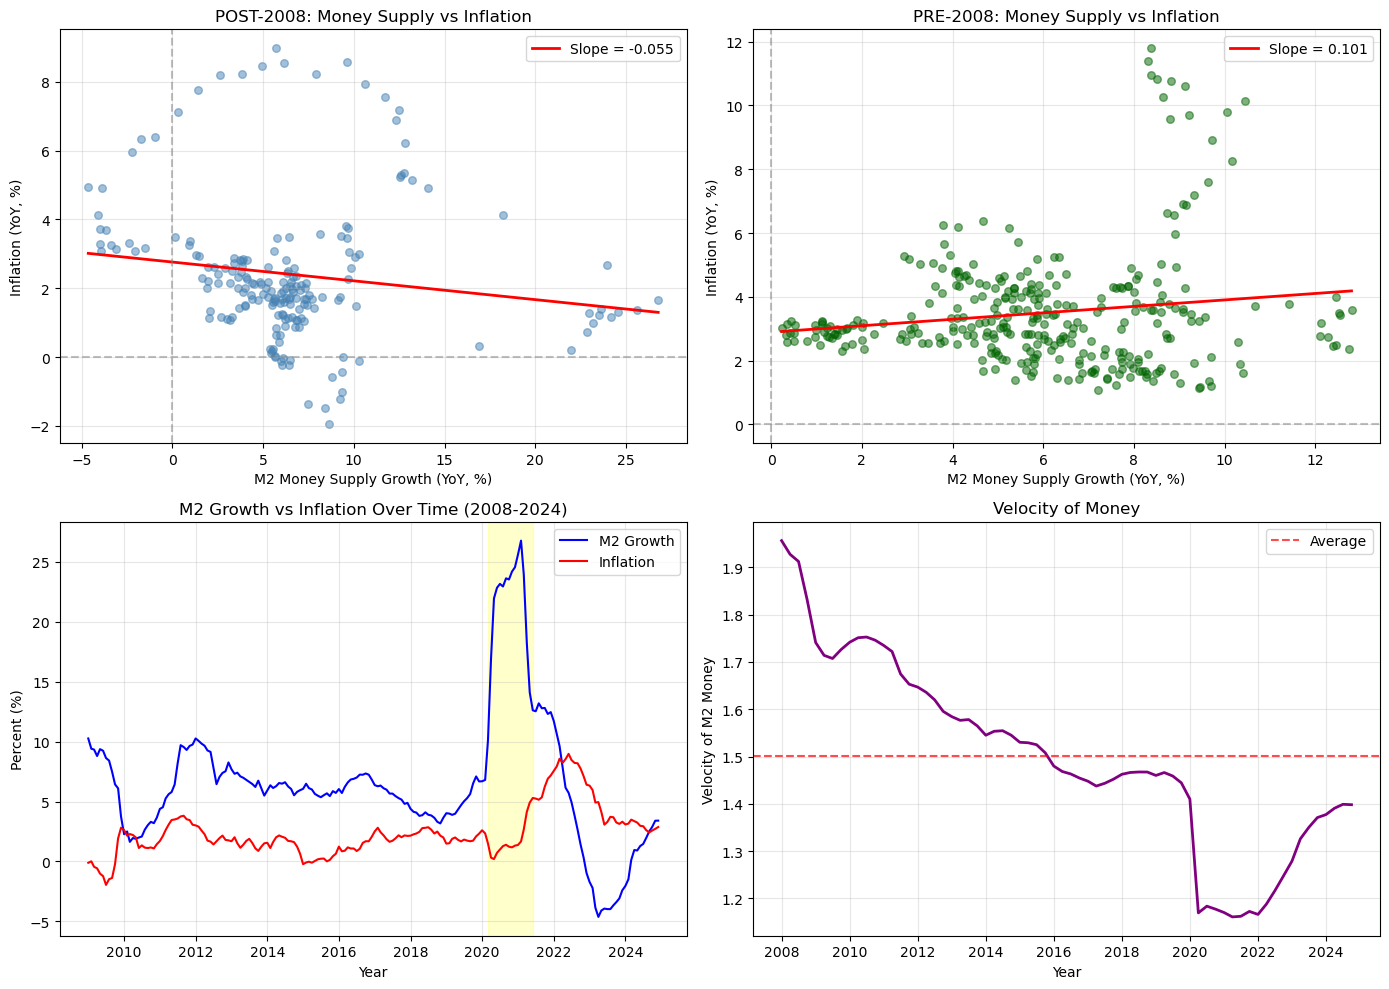

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from datetime import datetime
import pandas_datareader.data as web
import warnings
warnings.filterwarnings('ignore')

# FETCH DATA

start = datetime(2008, 1, 1)  # Post-2008 focus
end = datetime(2024, 12, 31)

# M2 Money Supply (broad money)
m2 = web.DataReader('M2SL', 'fred', start, end)

# Consumer Price Index (inflation)
cpi = web.DataReader('CPIAUCSL', 'fred', start, end)

# For comparison, also get pre-2008 data
start_pre = datetime(1980, 1, 1)
end_pre = datetime(2007, 12, 31)

m2_pre = web.DataReader('M2SL', 'fred', start_pre, end_pre)
cpi_pre = web.DataReader('CPIAUCSL', 'fred', start_pre, end_pre)

# PREPARE DATA

# Post-2008 data (12-month % changes)
data_post = pd.DataFrame({
    'M2_Growth': m2['M2SL'].pct_change(12) * 100,
    'Inflation': cpi['CPIAUCSL'].pct_change(12) * 100
}).dropna()

# Pre-2008 data
data_pre = pd.DataFrame({
    'M2_Growth': m2_pre['M2SL'].pct_change(12) * 100,
    'Inflation': cpi_pre['CPIAUCSL'].pct_change(12) * 100
}).dropna()

print(f"   ✓ Post-2008: {len(data_post)} monthly observations (2008-2024)")
print(f"   ✓ Pre-2008: {len(data_pre)} monthly observations (1980-2007)")

# RUN REGRESSIONS

# Post-2008 regression
X_post = sm.add_constant(data_post['M2_Growth'])
y_post = data_post['Inflation']
model_post = sm.OLS(y_post, X_post).fit()

# Pre-2008 regression (for comparison)
X_pre = sm.add_constant(data_pre['M2_Growth'])
y_pre = data_pre['Inflation']
model_pre = sm.OLS(y_pre, X_pre).fit()

# PRINT RESULTS

print("\n" + "="*70)
print("POST-2008 RESULTS (2008-2024)")
print("="*70)
print(f"{'Variable':<25} {'Coefficient':<15} {'P-value':<15}")
print("-"*55)
print(f"{'Constant':<25} {model_post.params['const']:>12.3f} {model_post.pvalues['const']:>14.6f}")
print(f"{'M2 Growth (Money Supply)':<25} {model_post.params['M2_Growth']:>12.3f} {model_post.pvalues['M2_Growth']:>14.6f}")

print(f"\nR-squared: {model_post.rsquared:.4f} ({model_post.rsquared*100:.2f}% of inflation variation explained)")
print(f"Adjusted R-squared: {model_post.rsquared_adj:.4f}")

print("\n" + "="*70)
print("PRE-2008 RESULTS (1980-2007) - FOR COMPARISON")
print("="*70)
print(f"{'Variable':<25} {'Coefficient':<15} {'P-value':<15}")
print("-"*55)
print(f"{'Constant':<25} {model_pre.params['const']:>12.3f} {model_pre.pvalues['const']:>14.6f}")
print(f"{'M2 Growth (Money Supply)':<25} {model_pre.params['M2_Growth']:>12.3f} {model_pre.pvalues['M2_Growth']:>14.6f}")

print(f"\nR-squared: {model_pre.rsquared:.4f}")
print(f"Adjusted R-squared: {model_pre.rsquared_adj:.4f}")

# VISUALIZATIONS

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Post-2008 Scatter
ax1 = axes[0, 0]
ax1.scatter(data_post['M2_Growth'], data_post['Inflation'], alpha=0.5, s=30, color='steelblue')
x_range = np.linspace(data_post['M2_Growth'].min(), data_post['M2_Growth'].max(), 100)
y_pred = model_post.params['const'] + model_post.params['M2_Growth'] * x_range
ax1.plot(x_range, y_pred, 'r-', linewidth=2, label=f'Slope = {post_coef:.3f}')
ax1.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax1.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
ax1.set_xlabel('M2 Money Supply Growth (YoY, %)')
ax1.set_ylabel('Inflation (YoY, %)')
ax1.set_title('POST-2008: Money Supply vs Inflation')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Pre-2008 Scatter
ax2 = axes[0, 1]
ax2.scatter(data_pre['M2_Growth'], data_pre['Inflation'], alpha=0.5, s=30, color='darkgreen')
x_range_pre = np.linspace(data_pre['M2_Growth'].min(), data_pre['M2_Growth'].max(), 100)
y_pred_pre = model_pre.params['const'] + model_pre.params['M2_Growth'] * x_range_pre
ax2.plot(x_range_pre, y_pred_pre, 'r-', linewidth=2, label=f'Slope = {pre_coef:.3f}')
ax2.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax2.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
ax2.set_xlabel('M2 Money Supply Growth (YoY, %)')
ax2.set_ylabel('Inflation (YoY, %)')
ax2.set_title('PRE-2008: Money Supply vs Inflation')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: Time series - M2 Growth vs Inflation (Post-2008)
ax3 = axes[1, 0]
ax3.plot(data_post.index, data_post['M2_Growth'], 'b-', linewidth=1.5, label='M2 Growth')
ax3.plot(data_post.index, data_post['Inflation'], 'r-', linewidth=1.5, label='Inflation')
ax3.set_xlabel('Year')
ax3.set_ylabel('Percent (%)')
ax3.set_title('M2 Growth vs Inflation Over Time (2008-2024)')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 2020 money surge
ax3.axvspan('2020-03-01', '2021-06-01', alpha=0.2, color='yellow', label='COVID Money Surge')

# Plot 4: Velocity of Money (M2 Velocity)
# Calculate velocity: Nominal GDP / M2
gdp = web.DataReader('GDP', 'fred', start, end)
velocity = pd.DataFrame({
    'Velocity': gdp['GDP'] / m2['M2SL']
}).dropna()

ax4 = axes[1, 1]
ax4.plot(velocity.index, velocity['Velocity'], 'purple', linewidth=2)
ax4.set_xlabel('Year')
ax4.set_ylabel('Velocity of M2 Money')
ax4.set_title('Velocity of Money')
ax4.grid(True, alpha=0.3)
ax4.axhline(y=velocity['Velocity'].mean(), color='red', linestyle='--', alpha=0.7, label='Average')
ax4.legend()

plt.tight_layout()
plt.show()

The results show us that before 2008, the M2 growth coefficient was positive (as expected) and statistically significant, supporting the quantity theory of money. The adjusted R-squared tell us that M2 growth explained 2% of inflation variation. However, after 2008, the M2 growth coefficient was negative and statistically significant. According to economists, the reason for this was that, following the 2008 financial crisis, money circulated slower(shown in 'Velocity of Money' plot), banks lended very little, and the new money flowed into stocks and housing rather than consumer goods. Also, post-2008, the fed printed money to respond to low inflation, which is why there was low inflation and high M2 growth at the same time. 

The R-squared values for both periods are very low, suggesting that money supply is not a good predictor of inflation in either period. 